# Тематическая структура лирики Ю. В. Жадовской в рукописном альбоме и прижизненных сборниках: машинный анализ корпуса

## Цель проекта: 
## Исследовать тематическую структуру лирики Ю. В. Жадовской в рукописном альбоме и двух прижизненных сборниках с помощью методов машинного обучения и сравнить семантическую структуру трёх источников.

### Задачи:
### 1. Подготовить и провести разведочный анализ корпуса.
### 2. Представить тексты с помощью TF-IDF и семантических эмбеддингов.
### 3. Выявить группы семантически близких произведений методами кластеризации и сравнить несколько алгоритмов.
### 4. Сопоставить разные версии одних произведений в исследуемых источниках.
### 5. Сравнить семантическую структуру альбома и двух сборников.
### 6. Провести дополнительный эксперимент с нейросетевым сжатием семантических представлений.

### Логика проекта

Предполагалось, что методы машинного обучения позволят автоматически обнаружить тематические группы произведений без заранее заданных тематических категорий.

### Было сделано: 
#### - проведены EDA и частотный анализ; 
#### - тексты представлены через TF-IDF и семантические эмбеддинги; 
#### - применены KMeans, Agglomerative Clustering и DBSCAN; 
#### - сопоставлены версии произведений из разных источников; 
#### - источники проанализированы как вместе, так и по отдельности; 
#### - дополнительно обучен автоэнкодер.

### Получилось: 
в общем корпусе обнаружены отдельные интерпретируемые тематические ядра, однако чёткой системы изолированных тематических групп не возникло. При отдельной кластеризации источников устойчиво проявилось более крупное противопоставление двух семантических полюсов — условно «внешнего мира» и «внутреннего мира». В альбоме и первом сборнике их соотношение оказалось практически одинаковым, тогда как во втором сборнике доля «внешнего» полюса заметно выше.

### Не получилось: 
автоматически разделить весь корпус на несколько чётких и однозначно интерпретируемых тем. Невысокие значения silhouette score и визуализации показали, что границы между семантическими группами размыты.

### Дополнительный результат: 
обученный автоэнкодер сжал семантические представления с 384 до 32 признаков; 
после этого максимальный silhouette score KMeans незначительно вырос — с 0,1045 до 0,1249.

## 1. Подготовка корпуса

### 1.1. Загрузка и проверка корпуса

In [10]:
from pathlib import Path

In [11]:
#Указываю путь
corpus_path = Path(r"D:\Машинное обучение\Лекции и практика\Итоговый проект\zhadovskaya")

In [12]:
#Проверяю
corpus_path.exists()

True

In [13]:
#Проверяю, что лежит в папке
list(corpus_path.iterdir())

[WindowsPath('D:/Машинное обучение/Лекции и практика/Итоговый проект/zhadovskaya/album'),
 WindowsPath('D:/Машинное обучение/Лекции и практика/Итоговый проект/zhadovskaya/collection_1'),
 WindowsPath('D:/Машинное обучение/Лекции и практика/Итоговый проект/zhadovskaya/collection_2')]

In [14]:
#Проверяю, сколько текстов в альбоме
album_files = list((corpus_path / "album").glob("*.txt"))
len(album_files)

72

In [15]:
#Проверяю, сколько текстов в 1 сб
collection_1_files = list((corpus_path / "collection_1").glob("*.txt"))
len(collection_1_files)

58

In [16]:
#Проверяю, сколько текстов во 2 сб
collection_2_files = list((corpus_path / "collection_2").glob("*.txt"))
len(collection_2_files)

119

In [19]:
#Проверяю первый файл в альбоме
album_files[0]

WindowsPath('D:/Машинное обучение/Лекции и практика/Итоговый проект/zhadovskaya/album/001_Жизнь и море (Дума).txt')

In [20]:
#Проверяю, нормально ли отображается
text = album_files[0].read_text(encoding="utf-8")
print(text)

Жизнь и море (Дума) 

Жемчужные волны угрюмого моря!
Куда вы стремитесь, куда вы спешите,
Толкая друг друга? У вас ведь нет горя,
Заботы житейской! Куда ж вы бежите,
С тревогой, стараясь друг друга 
Ничтожить? Уже ли и вас холодные страсти
И чёрная зависть людского недуга
Тревожат и движут? Какой вы напасти
Спешите избегнуть в бесплодном бореньи?
Иль берег душистый вас к пристани верной
Вас тянет и манит красою творенья?
Но ветр утихает, и снова безмерной
Пучины спокойно чело, и волны
Не бьются, не ропщут, не плещут…
В них небо глядится, и утлые челны
Плывут безопасно, и солнышко блещет;
А люди?... житейское море
Без отдыху ветер порока волнует
Нет отблеска неба в сердцах! О счастии споря
В ничтожности ищут его и страшно бушуют
В них зависть и злоба.



In [22]:
#Проверяю имя файла без пути и без txt
album_files[0].stem

'001_Жизнь и море (Дума)'

### 1.2. Формирование таблицы корпуса 

In [23]:
#Загружаю библиотеку, с помощью которой буду составлять таблицу
import pandas as pd

In [24]:
#Делаю одну строку таблицы
row = {
    "source": "album",
    "file": album_files[0].name,
    "text": album_files[0].read_text(encoding="utf-8")
}

In [25]:
row

{'source': 'album',
 'file': '001_Жизнь и море (Дума).txt',
 'text': 'Жизнь и море (Дума) \n\nЖемчужные волны угрюмого моря!\nКуда вы стремитесь, куда вы спешите,\nТолкая друг друга? У вас ведь нет горя,\nЗаботы житейской! Куда ж вы бежите,\nС тревогой, стараясь друг друга \nНичтожить? Уже ли и вас холодные страсти\nИ чёрная зависть людского недуга\nТревожат и движут? Какой вы напасти\nСпешите избегнуть в бесплодном бореньи?\nИль берег душистый вас к пристани верной\nВас тянет и манит красою творенья?\nНо ветр утихает, и снова безмерной\nПучины спокойно чело, и волны\nНе бьются, не ропщут, не плещут…\nВ них небо глядится, и утлые челны\nПлывут безопасно, и солнышко блещет;\nА люди?... житейское море\nБез отдыху ветер порока волнует\nНет отблеска неба в сердцах! О счастии споря\nВ ничтожности ищут его и страшно бушуют\nВ них зависть и злоба.\n'}

In [26]:
#Собираю все файлы в таблицу
rows = []

for source in ["album", "collection_1", "collection_2"]:
    folder = corpus_path / source

    for file in sorted(folder.glob("*.txt")):
        rows.append({
            "source": source,
            "file": file.name,
            "text": file.read_text(encoding="utf-8").strip()
        })

df = pd.DataFrame(rows)

df.shape

(249, 3)

In [27]:
#Добавляю ещё номера текстов и заглавие имени файла
df["number"] = df["file"].str.extract(r"^(\d+)")[0].astype(int)

df["title"] = (
    df["file"]
    .str.replace(".txt", "", regex=False)
    .str.replace(r"^\d+_", "", regex=True)
)

df.loc[df["title"].str.fullmatch(r"\d+"), "title"] = None

df.head()

,source,file,text,number,title
0,album,001_Жизнь и море (Дума).txt,Жизнь и море (Дума) \n\nЖемчужные волны угрюмо...,1,Жизнь и море (Дума)
1,album,002_Клад.txt,"Клад \n\nЕсть клад у меня многоценный,\nГлубо...",2,Клад
2,album,003_Стремление.txt,"Стремление \n\nТуда! высоко, к небесам!..\nМне...",3,Стремление
3,album,004_Непонятное.txt,Непонятное \n\nБывают минуты – мне их не поня...,4,Непонятное
4,album,005_Воспоминание.txt,Воспоминание \n\nКак часто уношусь я резвою м...,5,Воспоминание


In [29]:
#Смотрю, сколько файлов без заглавия
df[df["title"].isna()][["source", "file"]]

,source,file
8,album,009.txt
13,album,014.txt
16,album,017.txt
17,album,018.txt
21,album,022.txt
...,...,...
240,collection_2,111.txt
243,collection_2,114.txt
245,collection_2,116.txt
246,collection_2,117.txt


In [30]:
#Создаю poem_text, у озаглавленных текстов убираю заглавие в самих текстах, сразу проверяю
def get_poem_text(row):
    text = row["text"].strip()

    if pd.isna(row["title"]):
        return text

    lines = text.splitlines()

    if lines and lines[0].strip() == row["title"].strip():
        lines = lines[1:]

    return "\n".join(lines).strip()


df["poem_text"] = df.apply(get_poem_text, axis=1)

df[["title", "poem_text"]].head()

,title,poem_text
0,Жизнь и море (Дума),Жемчужные волны угрюмого моря!\nКуда вы стреми...
1,Клад,"Есть клад у меня многоценный,\nГлубоко, глубок..."
2,Стремление,"Туда! высоко, к небесам!..\nМне тесно; сердце ..."
3,Непонятное,Бывают минуты – мне их не понять – \nТо чудные...
4,Воспоминание,"Как часто уношусь я резвою мечтой\nВ места, гд..."


### 1.3. Проверка качества корпуса

In [31]:
print("Количество текстов:", len(df))
print("Пустые тексты:", df["poem_text"].str.strip().eq("").sum())
print("Полные дубликаты:", df["poem_text"].duplicated().sum())

Количество текстов: 249
Пустые тексты: 0
Полные дубликаты: 1


In [32]:
#Смотрю, что за дубликаты
duplicate_mask = df["poem_text"].duplicated(keep=False)

df[duplicate_mask][["source", "file", "title"]]

,source,file,title
21,album,022.txt,None
129,collection_1,058.txt,None


## 2. Разведочный анализ корпуса (EDA)

In [33]:
#Запускаю библиотеку для графиков+кол-во источников
import matplotlib.pyplot as plt

source_counts = df["source"].value_counts().reindex(
    ["album", "collection_1", "collection_2"]
)

source_counts

source
album            72
collection_1     58
collection_2    119
Name: count, dtype: int64

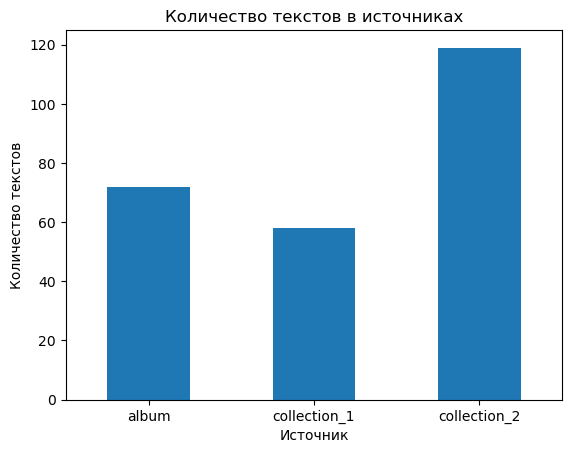

In [34]:
#Строю график
source_counts.plot(kind="bar")

plt.title("Количество текстов в источниках")
plt.xlabel("Источник")
plt.ylabel("Количество текстов")
plt.xticks(rotation=0)
plt.show()

In [35]:
#Добавляю новый столбец для кол-ва слов
df["word_count"] = df["poem_text"].str.split().str.len()

In [36]:
#Смотрю статистику кол-ва слов
length_stats = df.groupby("source")["word_count"].agg(
    ["count", "mean", "median", "min", "max"]
)

length_stats = length_stats.reindex(
    ["album", "collection_1", "collection_2"]
)

length_stats.round(1)

,count,mean,median,min,max
source,,,,,
album,72,89.8,84.0,22,252
collection_1,58,81.8,72.5,29,252
collection_2,119,105.1,76.0,29,768


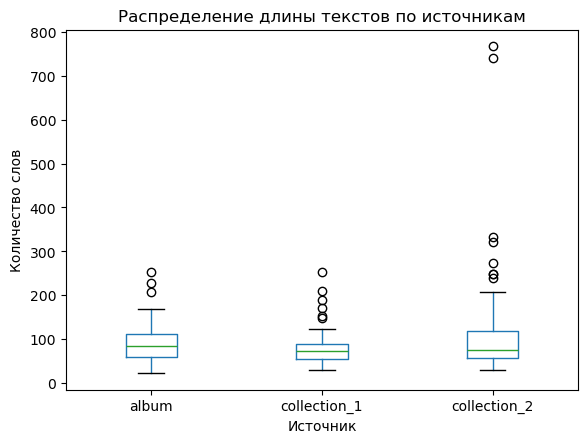

In [37]:
#Визуализирую это распределение
df.boxplot(
    column="word_count",
    by="source",
    grid=False
)

plt.title("Распределение длины текстов по источникам")
plt.suptitle("")
plt.xlabel("Источник")
plt.ylabel("Количество слов")
plt.show()

#### По медианной длине тексты сборников не очень различаются. Но во втором сборнике средняя длина выше остальных. Это объясняется тем, что во втором сборнике есть циклы стихотворений, но я их рассматриваю как единое целое, как одну единицу. Выбросы в collection_2 - это как раз, скорее всего, циклы и последняя поэма.

### 2.1. Токенизация

In [38]:
#Токенизация
import re

def tokenize(text):
    return re.findall(r"[а-яё]+", text.lower())

df["tokens"] = df["poem_text"].apply(tokenize)

df[["poem_text", "tokens"]].head(2)

,poem_text,tokens
0,Жемчужные волны угрюмого моря!\nКуда вы стреми...,"[жемчужные, волны, угрюмого, моря, куда, вы, с..."
1,"Есть клад у меня многоценный,\nГлубоко, глубок...","[есть, клад, у, меня, многоценный, глубоко, гл..."


In [40]:
#Удаляю стоп-слова с помощью nltk, проверяю самые частотные 30 слов
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download("stopwords")

stop_words = set(stopwords.words("russian"))
stop_words.update(["иль", "её", "мою", "моей"])

all_tokens = [
    token
    for tokens in df["tokens"]
    for token in tokens
    if token not in stop_words
]

word_counts = Counter(all_tokens)

word_counts.most_common(30)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pasek\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('сердце', 120),
 ('всё', 83),
 ('тебе', 70),
 ('душе', 63),
 ('небо', 62),
 ('жизни', 61),
 ('друг', 59),
 ('души', 57),
 ('душу', 56),
 ('тихо', 55),
 ('жизнь', 47),
 ('люблю', 44),
 ('грустно', 42),
 ('твой', 42),
 ('лишь', 41),
 ('взор', 40),
 ('одна', 38),
 ('цветы', 37),
 ('чувства', 35),
 ('любовь', 35),
 ('душа', 35),
 ('сладко', 33),
 ('мир', 31),
 ('любви', 31),
 ('полна', 30),
 ('солнце', 28),
 ('людей', 27),
 ('тобой', 27),
 ('мной', 27),
 ('люди', 26)]

### 2.2. Лемматизация

In [41]:
!pip install pymorphy3

In [42]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

In [43]:
def lemmatize_tokens(tokens):
    return [
        morph.parse(token)[0].normal_form
        for token in tokens
        if token not in stop_words
    ]

df["lemmas"] = df["tokens"].apply(lemmatize_tokens)

In [44]:
all_lemmas = [
    lemma
    for lemmas in df["lemmas"]
    for lemma in lemmas
]

lemma_counts = Counter(all_lemmas)

lemma_counts.most_common(30)

[('душа', 236),
 ('сердце', 163),
 ('небо', 143),
 ('жизнь', 115),
 ('ты', 113),
 ('твой', 108),
 ('любить', 83),
 ('всё', 83),
 ('слеза', 83),
 ('друг', 79),
 ('звезда', 78),
 ('счастие', 77),
 ('любовь', 73),
 ('один', 69),
 ('святой', 62),
 ('свой', 62),
 ('человек', 61),
 ('чувство', 61),
 ('мой', 59),
 ('тоска', 56),
 ('взор', 55),
 ('тихо', 55),
 ('мир', 52),
 ('цветок', 50),
 ('глядеть', 50),
 ('радость', 49),
 ('светлый', 48),
 ('мечта', 48),
 ('дума', 47),
 ('сила', 47)]

In [48]:
#Дополнительно добавляю стоп-леммы
extra_stop_lemmas = {"ты", "твой", "свой", "мой", "всё", "лишь", "весь"}

def lemmatize_tokens(tokens):
    lemmas = [
        morph.parse(token)[0].normal_form
        for token in tokens
        if token not in stop_words
    ]
    
    return [
        lemma
        for lemma in lemmas
        if lemma not in extra_stop_lemmas
    ]

df["lemmas"] = df["tokens"].apply(lemmatize_tokens)

In [49]:
#Снова считаю
all_lemmas = [
    lemma
    for lemmas in df["lemmas"]
    for lemma in lemmas
]

lemma_counts = Counter(all_lemmas)

lemma_counts.most_common(30)

[('душа', 236),
 ('сердце', 163),
 ('небо', 143),
 ('жизнь', 115),
 ('любить', 83),
 ('слеза', 83),
 ('друг', 79),
 ('звезда', 78),
 ('счастие', 77),
 ('любовь', 73),
 ('один', 69),
 ('святой', 62),
 ('человек', 61),
 ('чувство', 61),
 ('тоска', 56),
 ('взор', 55),
 ('тихо', 55),
 ('мир', 52),
 ('цветок', 50),
 ('глядеть', 50),
 ('радость', 49),
 ('светлый', 48),
 ('мечта', 48),
 ('дума', 47),
 ('сила', 47),
 ('полный', 46),
 ('прекрасный', 44),
 ('печальный', 43),
 ('надежда', 42),
 ('грустно', 42)]

### 2.3. Сравнение частотной лексики в сб-ках 

In [50]:
#Беру по 20 слов
def get_top_lemmas(source, n=20):
    lemmas = [
        lemma
        for text_lemmas in df.loc[df["source"] == source, "lemmas"]
        for lemma in text_lemmas
    ]
    
    return Counter(lemmas).most_common(n)


for source in ["album", "collection_1", "collection_2"]:
    print(f"\n{source}:")
    print(get_top_lemmas(source))


album:
[('душа', 68), ('сердце', 55), ('небо', 49), ('жизнь', 32), ('друг', 27), ('счастие', 27), ('любить', 25), ('слеза', 25), ('чувство', 23), ('человек', 20), ('земля', 20), ('святой', 20), ('светлый', 20), ('взор', 20), ('прекрасный', 20), ('один', 19), ('мечта', 19), ('радость', 19), ('дума', 18), ('звезда', 17)]

collection_1:
[('душа', 53), ('небо', 40), ('сердце', 36), ('звезда', 24), ('любить', 21), ('чувство', 20), ('жизнь', 20), ('счастие', 20), ('святой', 18), ('человек', 18), ('мир', 18), ('друг', 18), ('слеза', 17), ('любовь', 15), ('дума', 14), ('отрада', 14), ('взор', 14), ('радость', 14), ('один', 13), ('грустно', 13)]

collection_2:
[('душа', 115), ('сердце', 72), ('жизнь', 63), ('небо', 54), ('слеза', 41), ('любовь', 41), ('один', 37), ('звезда', 37), ('любить', 37), ('сила', 36), ('друг', 34), ('тоска', 32), ('цветок', 30), ('счастие', 30), ('тихо', 29), ('печальный', 28), ('видеть', 27), ('день', 26), ('дерево', 26), ('полный', 25)]


In [51]:
#Считаю, сколько кол-во лемм на 1 тыс лемм
def get_relative_frequency(source):
    lemmas = [
        lemma
        for text_lemmas in df.loc[df["source"] == source, "lemmas"]
        for lemma in text_lemmas
    ]

    counts = Counter(lemmas)
    total = len(lemmas)

    return {
        lemma: count / total * 1000
        for lemma, count in counts.items()
    }


relative_freqs = {
    source: get_relative_frequency(source)
    for source in ["album", "collection_1", "collection_2"]
}

In [52]:
#Делаю таблицу для 20 самых частотных
top_lemmas = [lemma for lemma, count in lemma_counts.most_common(20)]

freq_table = pd.DataFrame({
    source: {
        lemma: relative_freqs[source].get(lemma, 0)
        for lemma in top_lemmas
    }
    for source in ["album", "collection_1", "collection_2"]
})

freq_table.round(1)

,album,collection_1,collection_2
душа,17.7,18.4,15.1
сердце,14.3,12.5,9.5
небо,12.8,13.9,7.1
жизнь,8.3,6.9,8.3
любить,6.5,7.3,4.9
слеза,6.5,5.9,5.4
друг,7.0,6.2,4.5
звезда,4.4,8.3,4.9
счастие,7.0,6.9,3.9
любовь,4.4,5.2,5.4


#### Подсчёт показал, что наиболее частотная лексика представлена неодинаково в сб-ках.  

## 3. Векторизация текстов

### 3.1. TF-IDF 

In [53]:
#Собираю леммы обратно в одну строку
df["lemmatized_text"] = df["lemmas"].apply(" ".join)

df[["poem_text", "lemmatized_text"]].head(3)

,poem_text,lemmatized_text
0,Жемчужные волны угрюмого моря!\nКуда вы стреми...,жемчужный волна угрюмый море стремиться спешит...
1,"Есть клад у меня многоценный,\nГлубоко, глубок...",клад многоценный глубоко глубоко сердце зарыть...
2,"Туда! высоко, к небесам!..\nМне тесно; сердце ...",туда высоко небо тесно сердце воля просить дум...


In [54]:
#Команды: изучи корпус и составь словарь признаков, а после этого преврати каждый текст в числа
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(df["lemmatized_text"])

X_tfidf.shape

(249, 3127)

##### 249 строк - это 249 текстов, 3127 столбцов - это кол-во лемм, которые TF-IDF обнаружил в корпусе 

In [55]:
#Проверяю, какие слова получили самые большие веса, например, в 1 сх корпуса 
feature_names = tfidf.get_feature_names_out()

first_text_vector = X_tfidf[0].toarray()[0]

top_indices = first_text_vector.argsort()[-10:][::-1]

for index in top_indices:
    print(feature_names[index], round(first_text_vector[index], 3))

друг 0.235
зависть 0.23
спешить 0.202
волна 0.189
житейский 0.189
море 0.172
ветер 0.153
спорить 0.136
ничтожность 0.136
чело 0.136


## 4. Автоматическое выявление тематических групп

### 4.1. Кластеризация методом K-Means

#### K-Means разбивает тексты на заданное количество кластеров. А я не знаю это количество, поэтому попробую проверить разное кол-во K и сравнить с помощью с помощью silhouette score.

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 21):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_tfidf)
    
    score = silhouette_score(X_tfidf, labels)
    silhouette_scores[k] = score
    
    print(f"k={k}: {score:.4f}")

k=2: 0.0084
k=3: 0.0091
k=4: 0.0114
k=5: 0.0152
k=6: 0.0171
k=7: 0.0198
k=8: 0.0214
k=9: 0.0227
k=10: 0.0294
k=11: 0.0310
k=12: 0.0399
k=13: 0.0369
k=14: 0.0367
k=15: 0.0474
k=16: 0.0455
k=17: 0.0479
k=18: 0.0643
k=19: 0.0565
k=20: 0.0596


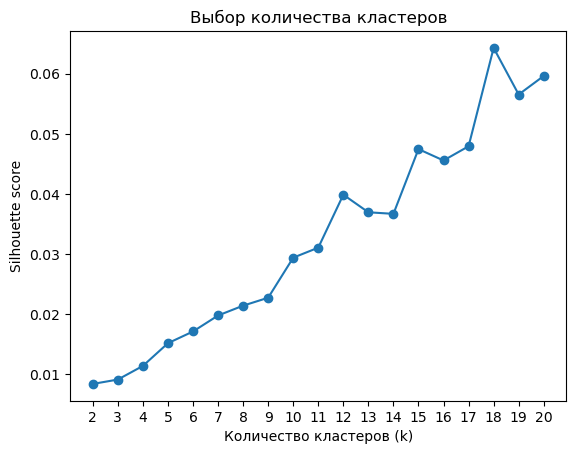

In [170]:
#Визуализирую полученные результаты
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Количество кластеров (k)")
plt.ylabel("Silhouette score")
plt.title("Выбор количества кластеров")
plt.xticks(range(2, 21))
plt.show()

In [64]:
#Пробую разделить на 5 групп
kmeans = KMeans(
    n_clusters=18,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_tfidf)

df["cluster"].value_counts().sort_index()

cluster
0      6
1     10
2      6
3     24
4     17
5     18
6     12
7     14
8      5
9     26
10     8
11     5
12     7
13     5
14     6
15    69
16     5
17     6
Name: count, dtype: int64

In [65]:
#Смотрю, какие самые частотные слова в каждой группе

In [69]:
import numpy as np

centers = kmeans.cluster_centers_

for cluster_num in range(18):
    top_indices = centers[cluster_num].argsort()[-15:][::-1]
    top_words = feature_names[top_indices]
    
    print(f"\nКластер {cluster_num}:")
    print(", ".join(top_words))


Кластер 0:
небесный, исцелить, вечно, сила, благость, благо, рана, ожить, божественный, прах, взять, благотворно, недужный, превечный, отвергнуть

Кластер 1:
прислушаться, туда, небо, безмолвный, звезда, оно, говорить, земля, звук, высоко, тесно, бесчисленный, наш, даль, дума

Кластер 2:
час, способность, минута, трудный, смерть, мир, всепеть, одетый, постичь, утрата, испытание, духовный, перестрадать, пережить, убито

Кластер 3:
бывать, мир, грустно, счастие, цветок, порою, душа, сердце, небо, чувство, божий, минута, прекрасный, дерево, окно

Кластер 4:
надежда, прежде, счастие, стать, глядеть, радостный, бывало, мечта, любить, искать, душа, жизнь, сердце, прежний, частый

Кластер 5:
звезда, пусть, небо, душа, веять, тишина, найти, святой, ответ, сладостно, едва, сердце, заря, природа, что

Кластер 6:
плач, слеза, мочь, часто, тревожный, понять, человек, изображать, проникнуть, око, участие, слушать, катиться, что, ложный

Кластер 7:
взор, любить, видать, безумный, улыбка, верить, не

In [73]:
#Проверяю количество стихотворений
df["cluster"].value_counts().sort_index()

cluster
0      6
1     10
2      6
3     24
4     17
5     18
6     12
7     14
8      5
9     26
10     8
11     5
12     7
13     5
14     6
15    69
16     5
17     6
Name: count, dtype: int64

In [74]:
#Вывожу названия сх в кластерах
for cluster_num in range(18):
    cluster_texts = df[df["cluster"] == cluster_num]
    
    print(f"\nКластер {cluster_num} — {len(cluster_texts)} текстов:")
    
    for _, row in cluster_texts.iterrows():
        title = row["title"] if pd.notna(row["title"]) else "Без названия"
        print(f"  {row['source']} | {row['file']} | {title}")


Кластер 0 — 6 текстов:
  album | 060_Величие и благость.txt | Величие и благость
  collection_1 | 053_Жажда небесного.txt | Жажда небесного
  collection_2 | 036_Жажда небесного.txt | Жажда небесного
  collection_2 | 083_Кто мне родня.txt | Кто мне родня
  collection_2 | 094.txt | Без названия
  collection_2 | 112_Молитва.txt | Молитва

Кластер 1 — 10 текстов:
  album | 003_Стремление.txt | Стремление
  album | 040_Ноктурно.txt | Ноктурно
  album | 050_Колокольня.txt | Колокольня
  album | 057_Пробужденье.txt | Пробужденье
  collection_1 | 004_Стремление.txt | Стремление
  collection_1 | 016_При чтении истории Петра Великого.txt | При чтении истории Петра Великого
  collection_1 | 048.txt | Без названия
  collection_1 | 049_Ноктурно.txt | Ноктурно
  collection_2 | 035_Ноктурно.txt | Ноктурно
  collection_2 | 095.txt | Без названия

Кластер 2 — 6 текстов:
  album | 038_Молитва.txt | Молитва
  album | 072_Тяжёлый час.txt | Тяжёлый час
  collection_1 | 033_Молитва.txt | Молитва
  collecti

### Обнаружила, что в одну группу попадают одинаковые стихотворения. Делаю вывод, что нужно идти по-другому, не только частотные слова выделять

### 4.2. Семантические эмбеддинги

In [75]:
!pip install sentence-transformers

In [76]:
from sentence_transformers import SentenceTransformer

In [77]:
#Беру обученную мультиязычную модель, она лучше для русского текста
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

C:\Users\pasek\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pasek\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [78]:
#Предлагаю для этой модели исходные тексты (poem_text)
embeddings = model.encode(
    df["poem_text"].tolist(),
    show_progress_bar=True
)

embeddings.shape

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

(249, 384)

In [79]:
#Ещё раз проверяю K-Means и k=2... - ...20
embedding_scores = {}

for k in range(2, 21):
    kmeans_emb = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans_emb.fit_predict(embeddings)
    
    score = silhouette_score(embeddings, labels)
    embedding_scores[k] = score
    
    print(f"k={k}: {score:.4f}")

C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=2: 0.0929
k=3: 0.0689
k=4: 0.0661


C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=5: 0.0597
k=6: 0.0741
k=7: 0.0713
k=8: 0.0703


C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=17: 0.0976
k=18: 0.1045


C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=19: 0.0961
k=20: 0.0891


C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


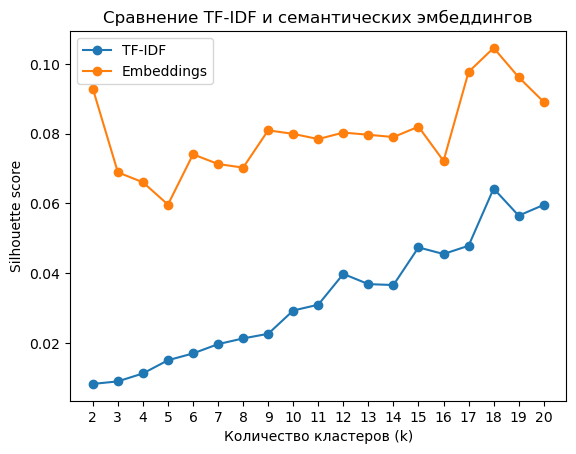

In [80]:
#Сравниваю на графике 
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o",
    label="TF-IDF"
)

plt.plot(
    list(embedding_scores.keys()),
    list(embedding_scores.values()),
    marker="o",
    label="Embeddings"
)

plt.xlabel("Количество кластеров (k)")
plt.ylabel("Silhouette score")
plt.title("Сравнение TF-IDF и семантических эмбеддингов")
plt.xticks(range(2, 21))
plt.legend()
plt.show()

#### Сравнение silhouette score показывает, что семантические эмбеддинги на всём рассмотренном диапазоне k дают более высокие значения, чем TF-IDF. Но интересно, что максимальное значение получено при k=18: 0.0643 для TF-IDF и 0.1045 для семантических эмбеддингов.

In [82]:
#Записываю результаты
kmeans_emb = KMeans(
    n_clusters=18,
    random_state=42,
    n_init=10
)

df["cluster_emb"] = kmeans_emb.fit_predict(embeddings)

C:\Users\pasek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [83]:
df["cluster_emb"].value_counts().sort_index()

cluster_emb
0     11
1     16
2     32
3     21
4      7
5      6
6     13
7      3
8      3
9      6
10    14
11    17
12    25
13     3
14    15
15    15
16    39
17     3
Name: count, dtype: int64

In [84]:
#Убираю предупреждение
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

In [86]:
#Просматриваю содержимое самых маленьких кластеров и самых больших
for cluster_num in [7, 8, 13, 17, 2, 12, 16]:
    cluster_texts = df[df["cluster_emb"] == cluster_num]

    print(f"\nКластер {cluster_num} — {len(cluster_texts)} текстов:")

    for _, row in cluster_texts.iterrows():
        title = row["title"] if pd.notna(row["title"]) else "Без названия"
        print(f"  {row['source']} | {title}")


Кластер 7 — 3 текстов:
  album | Без названия
  collection_1 | Без названия
  collection_2 | Без названия

Кластер 8 — 3 текстов:
  album | Без названия
  collection_1 | Без названия
  collection_2 | Без названия

Кластер 13 — 3 текстов:
  album | Вечерняя мысль
  collection_1 | Вечерняя мысль
  collection_2 | Вечерняя мысль

Кластер 17 — 3 текстов:
  album | Две сестры
  collection_1 | Две сестры
  collection_2 | Две сестры

Кластер 2 — 32 текстов:
  album | Стремление
  album | Ангелу-хранителю
  album | Молитва
  album | К...
  album | Молитва
  album | N.N.
  album | Совет
  album | Величие и благость
  collection_1 | Стремление
  collection_1 | Молитва
  collection_1 | Молитва
  collection_1 | К...
  collection_1 | Искушение
  collection_1 | Молитва
  collection_1 | Без названия
  collection_1 | Любовь
  collection_1 | Жажда небесного
  collection_1 | Монолог
  collection_1 | Без названия
  collection_2 | Молитва
  collection_2 | Молитва
  collection_2 | Искушение
  collection_2 

### Анализ состава кластеров показал, что часть небольших групп объединяет разные версии одного произведения из нескольких источников. Некоторые крупные кластеры объединяют разные произведения с предположительно близкой тематикой, например, наличие религиозно-духовного тематического ядра. То есть кластеризация с использованием эмбеддингов дала более интерпретируемый результат, чем TF-IDF.

## 5. Сопоставление произведений между источниками

#### Для сопоставления разных версий одного произведения используется идентификатор `work_id`. Тексты из разных источников сохраняются как отдельные единицы корпуса, но версии одного произведения получают общий идентификатор.

In [98]:
#считаю косинусное сходство между эмбеддингами
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

In [99]:
pairs = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):

        if df.iloc[i]["source"] == df.iloc[j]["source"]:
            continue

        pairs.append({
            "index_1": i,
            "index_2": j,
            "source_1": df.iloc[i]["source"],
            "source_2": df.iloc[j]["source"],
            "title_1": df.iloc[i]["title"],
            "title_2": df.iloc[j]["title"],
            "similarity": similarity_matrix[i, j]
        })

similar_pairs = (
    pd.DataFrame(pairs)
    .sort_values("similarity", ascending=False)
)

similar_pairs.head(30)

,index_1,index_2,source_1,source_2,title_1,title_2,similarity
3774,21,129,album,collection_1,None,None,1.000000
3813,21,168,album,collection_2,None,None,0.999035
19565,129,168,collection_1,collection_2,None,None,0.999035
5853,33,84,album,collection_1,None,None,0.998206
14181,84,139,collection_1,collection_2,None,None,0.996891
18967,124,165,collection_1,collection_2,Жажда небесного,Жажда небесного,0.996331
13460,78,132,collection_1,collection_2,Молитва,Молитва,0.995674
12744,72,130,collection_1,collection_2,None,None,0.995415
17772,114,160,collection_1,collection_2,None,None,0.995192
16698,105,157,collection_1,collection_2,Дитя,Дитя,0.993724


In [100]:
for threshold in [0.99, 0.98, 0.97, 0.95, 0.90, 0.85, 0.80]:
    count = (similar_pairs["similarity"] >= threshold).sum()
    print(f">= {threshold}: {count} пар")

>= 0.99: 24 пар
>= 0.98: 46 пар
>= 0.97: 62 пар
>= 0.95: 79 пар
>= 0.9: 92 пар
>= 0.85: 166 пар
>= 0.8: 528 пар


In [101]:
similar_pairs.iloc[80:110]

,index_1,index_2,source_1,source_2,title_1,title_2,similarity
357,2,75,album,collection_1,Стремление,Стремление,0.942241
5514,31,99,album,collection_1,Искушение,Искушение,0.941527
6805,38,151,album,collection_2,Вечер,Вечер,0.940271
214,1,109,album,collection_1,Клад,Клад,0.935328
6751,38,97,album,collection_1,Вечер,Вечер,0.931866
5560,31,145,album,collection_2,Искушение,Искушение,0.919681
14900,90,144,collection_1,collection_2,Теперь не то,Теперь не то,0.916746
6642,37,165,album,collection_2,Молитва,Жажда небесного,0.912835
13223,76,133,collection_1,collection_2,Водяной,Водяной,0.912624
6601,37,124,album,collection_1,Молитва,Жажда небесного,0.906126


In [102]:
titled = df[df["title"].notna()].copy()

same_title = (
    titled.groupby("title")
    .filter(lambda x: x["source"].nunique() > 1)
    .sort_values(["title", "source"])
)

same_title[["source", "number", "title"]]

,source,number,title
68,album,69,Ангел Хранитель
106,collection_1,35,Ангел Хранитель
125,collection_1,54,Бабушкин сад
167,collection_2,38,Бабушкин сад
54,album,55,Бывает
82,collection_1,11,Бывает
86,collection_1,15,В сумерки
141,collection_2,12,В сумерки
6,album,7,Ветер
122,collection_1,51,Ветер


In [103]:
print("Строк:", len(same_title))
print("Названий:", same_title["title"].nunique())

Строк: 92
Названий: 36


In [104]:
title_counts = (
    same_title
    .groupby("title")
    .size()
    .sort_values(ascending=False)
)

title_counts

title
Молитва                 9
Вечер и утро            3
Вечер                   3
Вечерняя мысль          3
Совет                   3
Русалка                 3
Тяжёлый час             3
Теперь не то            3
Две сестры              3
К...                    3
Искушение               3
Водяной                 3
Притворство             3
Ноктурно                3
Бабушкин сад            2
Ангел Хранитель         2
В сумерки               2
Бывает                  2
Дитя                    2
Возврат весны           2
Монолог                 2
Клад                    2
Жизнь и море (Дума)     2
История цветов          2
Жажда небесного         2
Ветер                   2
Ночь                    2
Невыдержанная борьба    2
Ребёнку (Дума)          2
Приближающаяся туча     2
Непонятное              2
Сожаление               2
Стремление              2
Соловей                 2
Цветок                  2
Я плачу                 2
dtype: int64

In [105]:
same_title.groupby("title")["source"].nunique().value_counts().sort_index()

source
2    23
3    13
Name: count, dtype: int64

In [106]:
ambiguous = df[
    df["title"].isin(["Молитва", "К..."])
][["source", "number", "title", "poem_text"]].copy()

ambiguous["beginning"] = ambiguous["poem_text"].apply(
    lambda text: " ".join(text.splitlines()[:4])
)

ambiguous[
    ["source", "number", "title", "beginning"]
].sort_values(["title", "source", "number"])

,source,number,title,beginning
24,album,25,К...,"К… Пойте вы мне песенки Русские, удалые,"
29,album,30,К...,К… С какою тайною отрадой Тебе всегда внима...
93,collection_1,22,К...,С какою тайною отрадой Тебе всегда внимаю я! Б...
23,album,24,Молитва,"Молю Тебя, Создатель мой, Смири во мне страсте..."
37,album,38,Молитва,"Мира Заступница, Матерь всепетая! Ныне к тебе ..."
78,collection_1,7,Молитва,"МОЛИТВА Молю Тебя, Создатель мой: Смири во мн..."
85,collection_1,14,Молитва,"МОЛИТВА К Тебе, Всемогущий, С душой утомлённой,"
104,collection_1,33,Молитва,"МОЛИТВА Мира Заступница, Матерь всепетая! Я п..."
132,collection_2,3,Молитва,"Молю Тебя, Создатель мой: Смири во мне страсте..."
140,collection_2,11,Молитва,"К Тебе, Всемогущий, С душой утомленной, Печаль..."


In [107]:
#Создаю work_id
df["work_id"] = range(1, len(df) + 1)

In [108]:
ambiguous_titles = ["Молитва", "К..."]

for title, group in df[
    df["title"].notna() &
    ~df["title"].isin(ambiguous_titles)
].groupby("title"):

    if group["source"].nunique() > 1:
        common_work_id = group["work_id"].min()
        df.loc[group.index, "work_id"] = common_work_id

In [109]:
def link_versions(indices):
    common_work_id = df.loc[indices, "work_id"].min()
    df.loc[indices, "work_id"] = common_work_id

In [110]:
# «К...» — «С какою тайною отрадой...»
link_versions([29, 93])

# «Молитва» — «Молю Тебя, Создатель мой...»
link_versions([23, 78, 132])

# «Молитва» — «Мира Заступница...»
link_versions([37, 104, 155])

# «Молитва» — «К Тебе, Всемогущий...»
link_versions([85, 140])

In [111]:
print("Строк в корпусе:", len(df))
print("Уникальных work_id:", df["work_id"].nunique())

Строк в корпусе: 249
Уникальных work_id: 197


In [112]:
unlinked_pairs = similar_pairs[
    similar_pairs.apply(
        lambda row:
        df.loc[row["index_1"], "work_id"] !=
        df.loc[row["index_2"], "work_id"],
        axis=1
    )
]

high_similarity_unlinked = unlinked_pairs[
    unlinked_pairs["similarity"] >= 0.95
]

high_similarity_unlinked[
    [
        "index_1", "index_2",
        "source_1", "source_2",
        "title_1", "title_2",
        "similarity"
    ]
]

,index_1,index_2,source_1,source_2,title_1,title_2,similarity
3774,21,129,album,collection_1,None,None,1.000000
3813,21,168,album,collection_2,None,None,0.999035
19565,129,168,collection_1,collection_2,None,None,0.999035
5853,33,84,album,collection_1,None,None,0.998206
14181,84,139,collection_1,collection_2,None,None,0.996891
12744,72,130,collection_1,collection_2,None,None,0.995415
17772,114,160,collection_1,collection_2,None,None,0.995192
2832,16,72,album,collection_1,None,None,0.993710
12120,68,156,album,collection_2,Ангел Хранитель,Ангел-хранитель,0.993633
5908,33,139,album,collection_2,None,None,0.993485


In [113]:
print("Кандидатов:", len(high_similarity_unlinked))

Кандидатов: 28


In [114]:
candidates = high_similarity_unlinked.copy()

candidates["beginning_1"] = candidates["index_1"].apply(
    lambda i: " ".join(df.loc[i, "poem_text"].splitlines()[:3])
)

candidates["beginning_2"] = candidates["index_2"].apply(
    lambda i: " ".join(df.loc[i, "poem_text"].splitlines()[:3])
)

candidates[
    [
        "index_1", "index_2",
        "source_1", "source_2",
        "title_1", "title_2",
        "similarity",
        "beginning_1", "beginning_2"
    ]
]

,index_1,index_2,source_1,source_2,title_1,title_2,similarity,beginning_1,beginning_2
3774,21,129,album,collection_1,None,None,1.000000,"Много капель светлых В сине море падает, Много...","Много капель светлых В сине море падает, Много..."
3813,21,168,album,collection_2,None,None,0.999035,"Много капель светлых В сине море падает, Много...",Много капель светлых В сине море падает; Много...
19565,129,168,collection_1,collection_2,None,None,0.999035,"Много капель светлых В сине море падает, Много...",Много капель светлых В сине море падает; Много...
5853,33,84,album,collection_1,None,None,0.998206,"Ты скоро меня позабудешь, Но я не забуду тебя....","Ты скоро меня позабудешь, Но я не забуду тебя;..."
14181,84,139,collection_1,collection_2,None,None,0.996891,"Ты скоро меня позабудешь, Но я не забуду тебя;...","Ты скоро меня позабудешь, Но я не забуду тебя;..."
12744,72,130,collection_1,collection_2,None,None,0.995415,Лучший перл таится В глубине морской; Зреет мы...,Лучший перл таится В глубине морской; Зреет мы...
17772,114,160,collection_1,collection_2,None,None,0.995192,"Всё ты уносишь, нещадное время – Горе и радост...","Все ты уносишь, нещадное время — Горе и радост..."
2832,16,72,album,collection_1,None,None,0.993710,Лучший перл таится В глубине морской; - Зреет ...,Лучший перл таится В глубине морской; Зреет мы...
12120,68,156,album,collection_2,Ангел Хранитель,Ангел-хранитель,0.993633,"Я видела тебя души моей очами: Ты радостен, ты...","Я видела Тебя души моей очами: Ты радостен, Ты..."
5908,33,139,album,collection_2,None,None,0.993485,"Ты скоро меня позабудешь, Но я не забуду тебя....","Ты скоро меня позабудешь, Но я не забуду тебя;..."


In [115]:
version_groups = [
    [21, 129, 168],
    [33, 84, 139],
    [16, 72, 130],
    [114, 160],
    [68, 106, 156],
    [45, 110, 161],
    [46, 83, 138],
    [103, 153],
    [107, 148],
    [95, 149],
    [19, 101, 154],
    [67, 105, 157],
    [60, 91],
    [8, 74],
    [116, 162],
]

for group in version_groups:
    link_versions(group)

In [116]:
print("Строк в корпусе:", len(df))
print("Уникальных work_id:", df["work_id"].nunique())

Строк в корпусе: 249
Уникальных work_id: 177


In [117]:
remaining_pairs = similar_pairs[
    similar_pairs.apply(
        lambda row:
        df.loc[row["index_1"], "work_id"] !=
        df.loc[row["index_2"], "work_id"],
        axis=1
    )
]

borderline_pairs = remaining_pairs[
    (remaining_pairs["similarity"] >= 0.85) &
    (remaining_pairs["similarity"] < 0.95)
].copy()

print("Кандидатов:", len(borderline_pairs))

Кандидатов: 77


In [118]:
borderline_pairs["beginning_1"] = borderline_pairs["index_1"].apply(
    lambda i: " ".join(df.loc[i, "poem_text"].splitlines()[:3])
)

borderline_pairs["beginning_2"] = borderline_pairs["index_2"].apply(
    lambda i: " ".join(df.loc[i, "poem_text"].splitlines()[:3])
)

borderline_pairs[
    [
        "index_1", "index_2",
        "source_1", "source_2",
        "title_1", "title_2",
        "similarity",
        "beginning_1", "beginning_2"
    ]
].head(40)

,index_1,index_2,source_1,source_2,title_1,title_2,similarity,beginning_1,beginning_2
6642,37,165,album,collection_2,Молитва,Жажда небесного,0.912835,"Мира Заступница, Матерь всепетая! Ныне к тебе ...","Исцели меня, Благость превечная! Исцели мои ра..."
6601,37,124,album,collection_1,Молитва,Жажда небесного,0.906126,"Мира Заступница, Матерь всепетая! Ныне к тебе ...","ЖАЖДА НЕБЕСНОГО Исцели меня, Благость превечная!"
14326,85,165,collection_1,collection_2,Молитва,Жажда небесного,0.905672,"МОЛИТВА К Тебе, Всемогущий,","Исцели меня, Благость превечная! Исцели мои ра..."
16180,100,234,collection_1,collection_2,История цветов,None,0.903525,ИСТОРИЯ ЦВЕТОВ В весеннее время,"По зеленому лугу гуляя, Ты вчера так печальна ..."
18957,124,155,collection_1,collection_2,Жажда небесного,Молитва,0.897499,"ЖАЖДА НЕБЕСНОГО Исцели меня, Благость превечная!","Мира Заступница, Матерь всепетая! Я пред Тобою..."
16587,104,165,collection_1,collection_2,Молитва,Жажда небесного,0.894733,"МОЛИТВА Мира Заступница, Матерь всепетая!","Исцели меня, Благость превечная! Исцели мои ра..."
6813,38,159,album,collection_2,Вечер,Ночь,0.891340,Повсюду тишина: природа засыпает. Заря на запа...,"Веет тихо, веет сладостно Мне дыханье ветерка;..."
6562,37,85,album,collection_1,Молитва,Молитва,0.890548,"Мира Заступница, Матерь всепетая! Ныне к тебе ...","МОЛИТВА К Тебе, Всемогущий,"
4084,23,85,album,collection_1,Молитва,Молитва,0.890335,"Молю Тебя, Создатель мой, Смири во мне страсте...","МОЛИТВА К Тебе, Всемогущий,"
14316,85,155,collection_1,collection_2,Молитва,Молитва,0.889667,"МОЛИТВА К Тебе, Всемогущий,","Мира Заступница, Матерь всепетая! Я пред Тобою..."


## 6. Сравнение тематической структуры источников

### 6.1. Слои первого появления произведений

Часть произведений повторяется в нескольких источниках, поэтому для сравнения тематической структуры буду дополнительно учитывать первое
появление произведения в корпусе. Это позволяет отделить произведения альбома от текстов, впервые появившихся в первом и втором сборниках.

In [119]:
#Задаю порядок источников
source_order = {
    "album": 0,
    "collection_1": 1,
    "collection_2": 2
}

In [120]:
#Для каждого work_id нахожу самый ранний источник
first_source = (
    df.groupby("work_id")["source"]
    .apply(lambda x: min(x, key=lambda s: source_order[s]))
)

first_source.head()

work_id
1    album
2    album
3    album
4    album
5    album
Name: source, dtype: object

In [121]:
df["first_source"] = df["work_id"].map(first_source)

In [122]:
df[
    ["source", "title", "work_id", "first_source"]
].head(20)

,source,title,work_id,first_source
0,album,Жизнь и море (Дума),1,album
1,album,Клад,2,album
2,album,Стремление,3,album
3,album,Непонятное,4,album
4,album,Воспоминание,5,album
5,album,Отдохновение,6,album
6,album,Ветер,7,album
7,album,Забвение,8,album
8,album,None,9,album
9,album,Грустная минута,10,album


In [123]:
works = (
    df.sort_values(
        "source",
        key=lambda x: x.map(source_order)
    )
    .drop_duplicates("work_id")
    .copy()
)

works.shape

(177, 14)

In [124]:
works["first_source"].value_counts()

first_source
collection_2    80
album           72
collection_1    25
Name: count, dtype: int64

#### После сопоставления версий было выделено 177 предварительных групп произведений. Из них 72 представлены уже в рукописном альбоме, 25 впервые встречаются в первом сборнике и 80 — во втором сборнике.

In [125]:
cluster_by_layer = pd.crosstab(
    works["first_source"],
    works["cluster_emb"]
)

cluster_by_layer

cluster_emb,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
first_source,,,,,,,,,,,,,,,,,,
album,3,5,8,5,2,2,4,1,1,2,7,4,13,1,2,4,7,1
collection_1,2,0,6,2,1,0,0,0,0,0,1,2,4,0,2,1,4,0
collection_2,0,6,6,9,0,3,6,0,0,2,1,10,4,0,8,5,20,0


In [126]:
cluster_by_layer_percent = pd.crosstab(
    works["first_source"],
    works["cluster_emb"],
    normalize="index"
) * 100

cluster_by_layer_percent.round(1)

cluster_emb,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
first_source,,,,,,,,,,,,,,,,,,
album,4.2,6.9,11.1,6.9,2.8,2.8,5.6,1.4,1.4,2.8,9.7,5.6,18.1,1.4,2.8,5.6,9.7,1.4
collection_1,8.0,0.0,24.0,8.0,4.0,0.0,0.0,0.0,0.0,0.0,4.0,8.0,16.0,0.0,8.0,4.0,16.0,0.0
collection_2,0.0,7.5,7.5,11.2,0.0,3.8,7.5,0.0,0.0,2.5,1.2,12.5,5.0,0.0,10.0,6.2,25.0,0.0


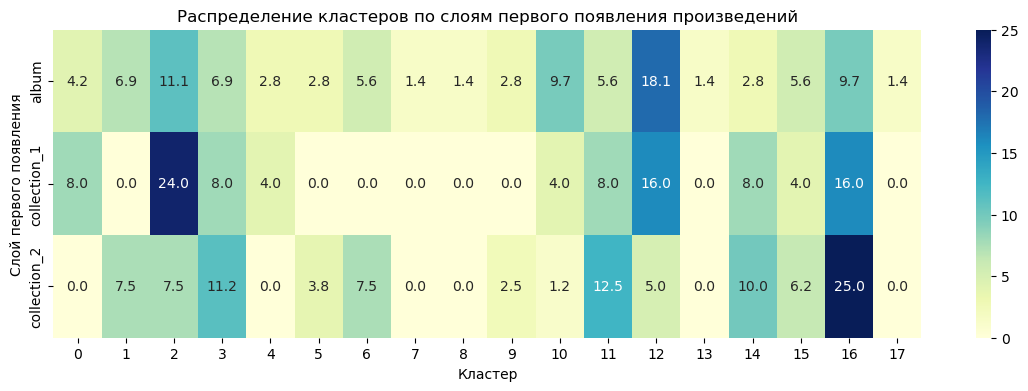

In [128]:
#Визуализирую тепловую карту
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 4))

sns.heatmap(
    cluster_by_layer_percent,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.xlabel("Кластер")
plt.ylabel("Слой первого появления")
plt.title("Распределение кластеров по слоям первого появления произведений")

plt.show()

### Cравнила распределение 18 кластеров по слоям первого появления произведений (в альбоме, первом и втором сборниках). Числа показывают долю каждого кластера в соответствующем слое в процентах. Видно, что распределение меняется: например, кластер 2 очень выделяется в первом сборнике (24%), кластер 12 — в альбоме (18,1%), а кластер 16 — во втором сборнике (25%). Это показывает, что автоматически выделенные семантические группы представлены в источниках неодинаково.

## 7. Сравнение методов кластеризации

### 7.1. Agglomerative Clustering

In [130]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

agg_scores = {}

for k in range(2, 31):
    model_agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model_agg.fit_predict(embeddings)

    score = silhouette_score(embeddings, labels)
    agg_scores[k] = score

    print(f"k={k}: {score:.4f}")

k=2: 0.0929
k=3: 0.0513
k=4: 0.0627
k=5: 0.0583
k=6: 0.0466
k=7: 0.0502
k=8: 0.0587
k=9: 0.0602
k=10: 0.0655
k=11: 0.0714
k=12: 0.0734
k=13: 0.0755
k=14: 0.0706
k=15: 0.0738
k=16: 0.0793
k=17: 0.0842
k=18: 0.0888
k=19: 0.0907
k=20: 0.0957
k=21: 0.1073
k=22: 0.1091
k=23: 0.1153
k=24: 0.1200
k=25: 0.1154
k=26: 0.1204
k=27: 0.1235
k=28: 0.1267
k=29: 0.1339
k=30: 0.1366


#### При агломеративной кластеризации значение silhouette score возрастает при увеличении числа кластеров. Однако увеличение числа кластеров приводит к более сильному дроблению небольшого корпуса, поэтому выбор модели неверный.

### 7.2. DBSCAN

In [131]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

for eps in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=3,
        metric="cosine"
    )

    labels = dbscan.fit_predict(embeddings)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters > 1:
        score = silhouette_score(
            embeddings,
            labels,
            metric="cosine"
        )
        score_text = f"{score:.4f}"
    else:
        score_text = "не вычисляется"

    print(
        f"eps={eps}: "
        f"кластеров={n_clusters}, "
        f"шум={n_noise}, "
        f"silhouette={score_text}"
    )

eps=0.1: кластеров=21, шум=181, silhouette=-0.0645
eps=0.15: кластеров=18, шум=139, silhouette=-0.0371
eps=0.2: кластеров=8, шум=62, silhouette=-0.0159
eps=0.25: кластеров=3, шум=21, silhouette=0.1316
eps=0.3: кластеров=1, шум=8, silhouette=не вычисляется
eps=0.35: кластеров=1, шум=3, silhouette=не вычисляется
eps=0.4: кластеров=1, шум=1, silhouette=не вычисляется


#### DBSCAN показал высокую чувствительность к параметру eps. При малых значениях большая часть корпуса определяется как шум, а при eps >= 0.3 практически все тексты объединяются в один кластер.

### Наиболее интерпретируемый результат среди проверенных параметров получен при eps=0.25: выделено 3 кластера, 21 текст отнесён к шуму. Таким образом, DBSCAN не выявил устойчивого разбиения корпуса на большое число плотных тематических групп.

### 7.3. Сравнение результатов кластеризации

In [133]:
comparison = pd.DataFrame({
    "Метод": [
        "KMeans",
        "Agglomerative Clustering",
        "DBSCAN"
    ],
    "Параметры": [
        "k=18",
        "k=30",
        "eps=0.25, min_samples=3"
    ],
    "Результат": [
        "18 кластеров",
        "30 кластеров",
        "3 кластера, 21 текст — шум"
    ],
    "Silhouette": [
        0.1045,
        0.1366,
        0.1316
    ]
})

comparison

,Метод,Параметры,Результат,Silhouette
0,KMeans,k=18,18 кластеров,0.1045
1,Agglomerative Clustering,k=30,30 кластеров,0.1366
2,DBSCAN,"eps=0.25, min_samples=3","3 кластера, 21 текст — шум",0.1316


### Три метода кластеризации дали разные результаты.

#### 1. KMeans при k=18 показал silhouette score 0,1045. Полученные кластеры оказались достаточно подробными для дальнейшего анализа.

#### 2. При Agglomerative Clustering silhouette score увеличивался при росте числа кластеров и достиг 0,1366 при k=30. Однако такое разбиение сильнее дробит небольшой корпус на отдельные группы.

#### 3. DBSCAN оказался чувствителен к параметру eps. При малых значениях большая часть текстов определялась как шум, а при больших практически весь корпус объединялся в один кластер. При eps=0.25 были получены 3 кластера и 21 шумовой текст.

## Таким образом, разные методы не выявили единственного устойчивого разбиения корпуса на фиксированное число тематических групп. Для дальнейшего содержательного анализа используется результат KMeans с k=18, поскольку он даёт подробное разбиение корпуса и позволяет интерпретировать отдельные группы текстов.

## 8. Содержательная интерпретация кластеров

Для интерпретации автоматически полученных кластеров рассматриваются
входящие в них произведения и наиболее характерная для них лексика.
Названия тематических групп не задавались модели заранее, а формулируются
после кластеризации на основе состава полученных групп.

In [134]:
def show_cluster(cluster):
    subset = works[works["cluster_emb"] == cluster].copy()

    subset["beginning"] = subset["poem_text"].apply(
        lambda x: " ".join(x.splitlines()[:2])
    )

    return subset[
        ["first_source", "number", "title", "beginning"]
    ]

In [135]:
show_cluster(2)

,first_source,number,title,beginning
2,album,3,Стремление,"Туда! высоко, к небесам!.. Мне тесно; сердце в..."
22,album,23,Ангелу-хранителю,"Хранитель-Ангел мой, прости меня, прости! Как ..."
23,album,24,Молитва,"Молю Тебя, Создатель мой, Смири во мне страсте..."
29,album,30,К...,К…
37,album,38,Молитва,"Мира Заступница, Матерь всепетая! Ныне к тебе ..."
52,album,53,N.N.,"Мне жаль тебя: ты слишком, слишком рано Утрати..."
53,album,54,Совет,"В час, когда, волнуясь, Суетные страсти"
59,album,60,Величие и благость,Только лишь две добродетели есть: величье и бл...
85,collection_1,14,Молитва,МОЛИТВА
107,collection_1,36,None,"Я всё ещё его, безумная, люблю! При имени его ..."


In [136]:
show_cluster(12)

,first_source,number,title,beginning
5,album,6,Отдохновение,"Когда на улицах утихнет шум людской, И в сердц..."
9,album,10,Грустная минута,"Голубое небо тучи застилают, - Ретивое сердце ..."
14,album,15,Бывают дни,"Бывают дни, когда нас покидают Надежды, мысли ..."
20,album,21,Уединение,"Бегу несносных мне и говора, и шума. Мне хочет..."
25,album,26,Обман,"Когда невольно я в мечтанья погружусь, И мысли..."
27,album,28,Утешение,"Когда земная жизнь мне душу утомляет, И ум мра..."
31,album,32,Искушение,"Всё спит вокруг меня спокойным, сладким сном, ..."
35,album,36,None,"О, дайте мне попеть о счастье и любви! Зачем в..."
62,album,63,Убежище (из Гейне),"Поток журчащий, лес шумливый, Седая, голая ска..."
63,album,64,Прекрасная мечта,"Не всё же нам, о нежный друг мой, горевать. От..."


In [137]:
show_cluster(16)

,first_source,number,title,beginning
0,album,1,Жизнь и море (Дума),Жемчужные волны угрюмого моря! Куда вы стремит...
10,album,11,Соловей,"Полно! Будет уж, Соловей мой, петь; Сладки пес..."
24,album,25,К...,К…
26,album,27,М.П.С.,"Как счастия призрак, прекрасна она, Как пальма..."
39,album,40,Ноктурно,Уж полночь глухая. Ты думаешь: «Всё уж уснуло;...
48,album,49,Молись,"Когда удалена от шума и сует Свободна я душой,..."
66,album,67,Блаженство безумия,"«Мечты – безумие, пустой, нелепый, бред, Горяч..."
87,collection_1,16,При чтении истории Петра Великого,ПРИ ЧТЕНИИ ИСТОРИИ ПЕТРА ВЕЛИКОГО
95,collection_1,24,None,"Что так неожиданно Взор твой оживлён,"
115,collection_1,44,None,"Бывало прежде, я для чувств искала слов, Стара..."


### 8.1. Интерпретация отдельных кластеров

#### Содержательный анализ показал, что некоторые автоматически полученные кластеры имеют заметное тематическое ядро.

#### Например, в кластере 2 - произведения с религиозно-духовной проблематикой, в кластере 12 - произведения, связанные с переживаниями тоски и одиночества. Кластер 16 оказался неоднородным, поэтому однозначного тематического названия нет.

### Таким образом, некоторые автоматически полученные кластеры имеют хорошо заметное тематическое ядро, тогда как другие отражают более сложную семантическую близость текстов.

In [138]:
show_cluster(11)

,first_source,number,title,beginning
3,album,4,Непонятное,Бывают минуты – мне их не понять – То чудные ...
4,album,5,Воспоминание,"Как часто уношусь я резвою мечтой В места, где..."
11,album,12,Бессонница,Не спится мне. Как камень налегла На грудь мою...
47,album,48,Раздумье,"Полна различных странных дум, Я слушаю нестрой..."
86,collection_1,15,В сумерки,В СУМЕРКИ
116,collection_1,45,Вопрос о счастии,ВОПРОС О СЧАСТИИ
169,collection_2,40,None,Я вновь полна чудесных звуков И сладких песен ...
173,collection_2,44,Возрождение,"Во мгле печальных заблуждений, В тяжелом спе д..."
174,collection_2,45,Сила звуков,"Из ума у меня не выходит Все та песня, что пел..."
179,collection_2,50,Э. И. Губеру,"Средь прозаических забот, Средь глупостей пров..."


In [139]:
show_cluster(14)

,first_source,number,title,beginning
18,album,19,Сад,"Здесь я, под ивой густой отдохну, полюбуюсь пр..."
65,album,66,Весеннее чувство,"О, как лазурь небес прекрасна и светла! Отрадн..."
100,collection_1,29,История цветов,ИСТОРИЯ ЦВЕТОВ
125,collection_1,54,Бабушкин сад,БАБУШКИН САД
204,collection_2,75,Прощай (из Уланда),"О, прощай, моя радость, прощай! Суждено нам ра..."
215,collection_2,86,None,"Друг мой! видишь ли, по небу, Тучки вешния плывут"
216,collection_2,87,Неутоленная жажда,"В одно ароматное утро, Под каплями светлой росы,"
224,collection_2,95,None,"Тихо я бреду одна по саду, Под ногами желтый л..."
229,collection_2,100,None,"Здесь я, здесь, в благовонном саду, С нетерпен..."
231,collection_2,102,None,Летний полдень страстным зноем Землю пышную то...


#### В кластере 11 заметно рефлексивно-психологическое ядро. Доля этого кластера увеличивается от 5,6% в альбомном слое до 8% в слое первого сборника и 12,5% в слое второго сборника.

#### Кластер 14 имеет выраженное природно-пейзажное ядро. Его доля также увеличивается: от 2,8% в альбомном слое до 8% в первом сборнике и 10% во втором.

### Таким образом, сравнение слоёв первого появления позволяет увидеть изменения долей групп, которые были автоматически обнаружены при кластеризации. 

## 9. Визуализация

In [140]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
)

embeddings_2d = tsne.fit_transform(embeddings)

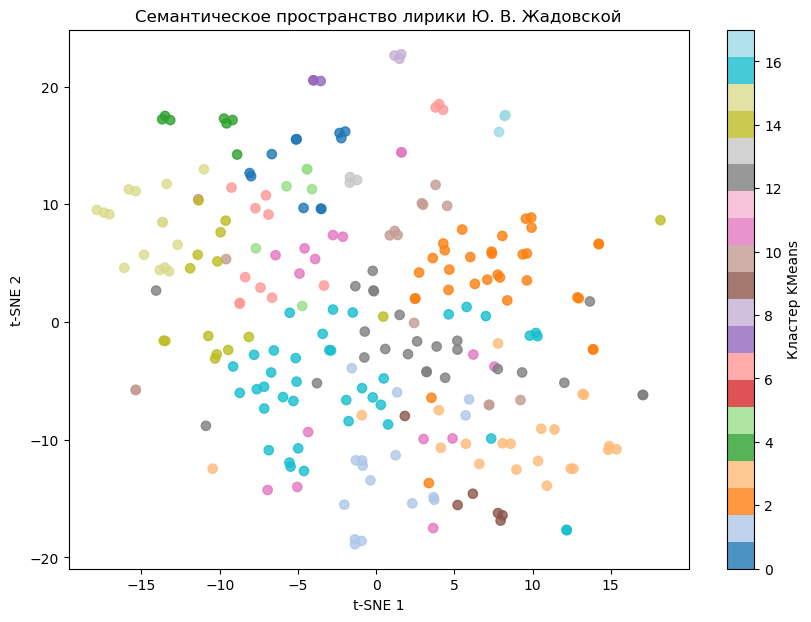

In [142]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["cluster_emb"],
    cmap="tab20",
    s=45,
    alpha=0.8
)

plt.colorbar(scatter, label="Кластер KMeans")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Семантическое пространство лирики Ю. В. Жадовской")
plt.show()

In [176]:
plot_3d = pd.DataFrame({
    "x": embeddings_3d[:, 0],
    "y": embeddings_3d[:, 1],
    "z": embeddings_3d[:, 2],
    "cluster": df["cluster_emb"].astype(str),
    "title": df["title"].fillna("Без названия"),
    "source": df["source"]
})

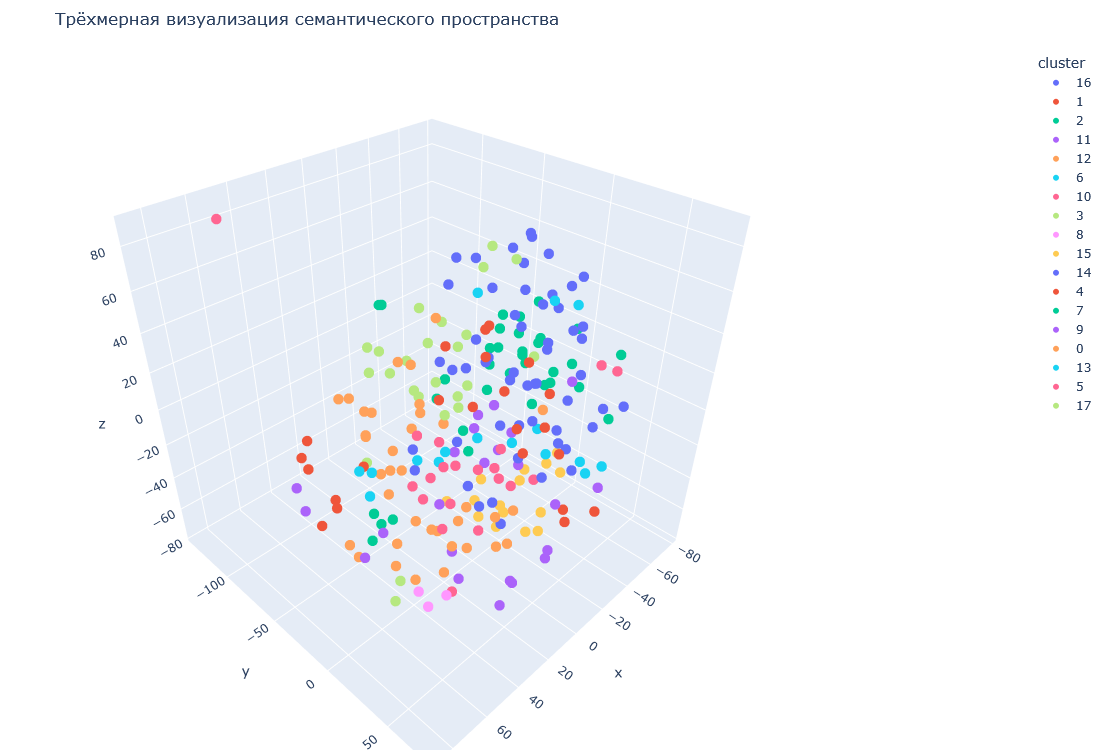

In [177]:
fig = px.scatter_3d(
    plot_3d,
    x="x",
    y="y",
    z="z",
    color="cluster",
    hover_name="title",
    hover_data=["source"],
    title="Трёхмерная визуализация семантического пространства",
    width=1000,
    height=750
)

fig.update_traces(marker=dict(size=6))

fig.update_layout(
    scene=dict(
        domain=dict(x=[0, 0.85], y=[0, 1]),
        aspectmode="cube"
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

### Для дополнительной визуализации семантического пространства была построена трёхмерная t-SNE-проекция эмбеддингов. Добавление третьего измерения не выявило чёткого разделения кластеров. Это подтверждает, что границы между выделенными семантическими группами размыты.

Здесь для каждого источника отдельно подбиралось количество кластеров KMeans от 2 до 15. Для каждого варианта вычислялся silhouette score, чтобы определить, при каком числе кластеров тексты разделяются наиболее чётко.

## 10. Подбор количества кластеров для каждого источника
#### Я решила проверить, проявляется ли тематическая структура лучше, если анализировать источники не все вместе, а каждый отдельно.

In [151]:
def find_best_k_for_source(source, max_k=15):
    mask = df["source"] == source
    source_embeddings = embeddings[mask]

    scores = {}

    for k in range(2, min(max_k + 1, len(source_embeddings))):
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(source_embeddings)
        scores[k] = silhouette_score(source_embeddings, labels)

    return scores

In [152]:
album_scores = find_best_k_for_source("album")
collection_1_scores = find_best_k_for_source("collection_1")
collection_2_scores = find_best_k_for_source("collection_2")

print("ALBUM")
for k, score in album_scores.items():
    print(k, round(score, 4))

print("\nCOLLECTION 1")
for k, score in collection_1_scores.items():
    print(k, round(score, 4))

print("\nCOLLECTION 2")
for k, score in collection_2_scores.items():
    print(k, round(score, 4))

ALBUM
2 0.0829
3 0.0712
4 0.055
5 0.0483
6 0.0416
7 0.0478
8 0.0437
9 0.045
10 0.0412
11 0.0517
12 0.0337
13 0.0283
14 0.0375
15 0.0167

COLLECTION 1
2 0.1119
3 0.0862
4 0.0964
5 0.1005
6 0.0871
7 0.0892
8 0.0907
9 0.0674
10 0.0803
11 0.0575
12 0.0503
13 0.0485
14 0.0607
15 0.0595

COLLECTION 2
2 0.0912
3 0.0662
4 0.0573
5 0.05
6 0.0508
7 0.0475
8 0.042
9 0.0477
10 0.0471
11 0.0501
12 0.0446
13 0.0391
14 0.0331
15 0.0393


In [153]:
source_models = {}

for source in ["album", "collection_1", "collection_2"]:
    mask = df["source"] == source
    source_embeddings = embeddings[mask]

    model = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(source_embeddings)

    df.loc[mask, "source_cluster"] = labels

    source_models[source] = model

In [154]:
pd.crosstab(
    df["source"],
    df["source_cluster"]
)

source_cluster,0.0,1.0
source,,
album,20,52
collection_1,16,42
collection_2,56,63


In [155]:
def show_source_cluster(source, cluster):
    subset = df[
        (df["source"] == source) &
        (df["source_cluster"] == cluster)
    ].copy()

    subset["beginning"] = subset["poem_text"].apply(
        lambda x: " ".join(x.splitlines()[:2])
    )

    return subset[
        ["number", "title", "beginning"]
    ]

In [156]:
show_source_cluster("album", 0)

,number,title,beginning
4,5,Воспоминание,"Как часто уношусь я резвою мечтой В места, где..."
11,12,Бессонница,Не спится мне. Как камень налегла На грудь мою...
15,16,Приношение,"Куда ты так спешишь, о дева молодая, С букетом..."
17,18,None,"Я помню вечер тот, и тихий, и прекрасный: Был ..."
18,19,Сад,"Здесь я, под ивой густой отдохну, полюбуюсь пр..."
19,20,Я люблю смотреть,"Я люблю смотреть В ясну ноченьку,"
21,22,None,"Много капель светлых В сине море падает,"
30,31,Водяной,"Там, где на реке Мельница шумит,"
34,35,None,"Как часто я склонясь, бывало, над рекой Следил..."
36,37,Вечер и утро,Солнце уж скрылось; зарёю пурпурной запад зажё...


In [157]:
show_source_cluster("album", 1)

,number,title,beginning
0,1,Жизнь и море (Дума),Жемчужные волны угрюмого моря! Куда вы стремит...
1,2,Клад,"Есть клад у меня многоценный, Глубоко, глубоко..."
2,3,Стремление,"Туда! высоко, к небесам!.. Мне тесно; сердце в..."
3,4,Непонятное,Бывают минуты – мне их не понять – То чудные ...
5,6,Отдохновение,"Когда на улицах утихнет шум людской, И в сердц..."
6,7,Ветер,"Ах, ты буйный ветр, порывистый! Смело веешь ты..."
7,8,Забвение,"Ужель на всё, что к жизни нас манило И думы чу..."
8,9,None,"Не на земле ищи ты вдохновенья, Не в этой жизн..."
9,10,Грустная минута,"Голубое небо тучи застилают, - Ретивое сердце ..."
10,11,Соловей,"Полно! Будет уж, Соловей мой, петь; Сладки пес..."


In [158]:
import numpy as np

feature_names = tfidf.get_feature_names_out()

def describe_source_clusters(source, n_terms=15):
    source_df = df[df["source"] == source]

    for cluster in [0, 1]:
        indices = source_df[
            source_df["source_cluster"] == cluster
        ].index

        mean_tfidf = np.asarray(
            X_tfidf[indices].mean(axis=0)
        ).ravel()

        top_indices = mean_tfidf.argsort()[-n_terms:][::-1]
        top_terms = feature_names[top_indices]

        print(f"\n{source}, кластер {cluster}")
        print("Текстов:", len(indices))
        print(", ".join(top_terms))

In [159]:
describe_source_clusters("album")
describe_source_clusters("collection_1")
describe_source_clusters("collection_2")


album, кластер 0
Текстов: 20
небо, звезда, светлый, природа, душа, тихий, отрадный, смотреть, любить, сон, тихо, он, соловей, ветерок, гореть

album, кластер 1
Текстов: 52
душа, сердце, счастие, жизнь, друг, чувство, небо, слеза, мир, ум, надежда, человек, радость, любить, дума

collection_1, кластер 0
Текстов: 16
небо, звезда, окно, душа, гореть, светлый, веять, око, каждый, он, вечерний, глядеть, святой, хотеться, чудно

collection_1, кластер 1
Текстов: 42
душа, сердце, чувство, мир, счастие, любить, человек, святой, друг, слеза, жизнь, плач, взор, небо, дума

collection_2, кластер 0
Текстов: 56
душа, сердце, сила, слеза, любить, жизнь, любовь, мочь, пред, святой, один, полный, сон, чувство, глубоко

collection_2, кластер 1
Текстов: 63
небо, душа, звезда, цветок, жизнь, дерево, солнце, тихо, луч, немой, печальный, окно, день, сердце, глядеть


In [160]:
df["semantic_pole"] = None

df.loc[
    (df["source"] == "album") &
    (df["source_cluster"] == 0),
    "semantic_pole"
] = "Внешний мир"

df.loc[
    (df["source"] == "album") &
    (df["source_cluster"] == 1),
    "semantic_pole"
] = "Внутренний мир"

df.loc[
    (df["source"] == "collection_1") &
    (df["source_cluster"] == 0),
    "semantic_pole"
] = "Внешний мир"

df.loc[
    (df["source"] == "collection_1") &
    (df["source_cluster"] == 1),
    "semantic_pole"
] = "Внутренний мир"

# Во втором сборнике номера кластеров поменялись местами
df.loc[
    (df["source"] == "collection_2") &
    (df["source_cluster"] == 1),
    "semantic_pole"
] = "Внешний мир"

df.loc[
    (df["source"] == "collection_2") &
    (df["source_cluster"] == 0),
    "semantic_pole"
] = "Внутренний мир"

In [161]:
pole_percent = pd.crosstab(
    df["source"],
    df["semantic_pole"],
    normalize="index"
) * 100

pole_percent.round(1)

semantic_pole,Внешний мир,Внутренний мир
source,,
album,27.8,72.2
collection_1,27.6,72.4
collection_2,52.9,47.1


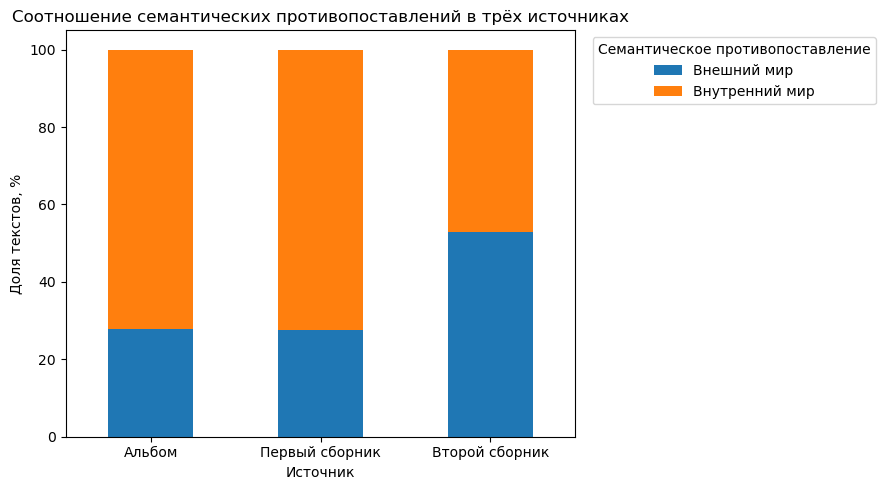

In [178]:
pole_percent_plot = pole_percent.rename(index={
    "album": "Альбом",
    "collection_1": "Первый сборник",
    "collection_2": "Второй сборник"
})

pole_percent_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.ylabel("Доля текстов, %")
plt.xlabel("Источник")
plt.title("Соотношение семантических противопоставлений в трёх источниках")

plt.legend(
    title="Семантическое противопоставление",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Во всех трёх источниках лучший результат среди проверенных вариантов был при k=2. Поэтому дальше я разделила каждый источник на два крупных кластера и увидела условные полюса «внешний мир» / «внутренний мир».

## 11. Нейросетевое сжатие семантических представлений

### Дополнительно провела эксперимент с автоэнкодером — нейронной сетью, которая обучается сжимать исходные семантические эмбеддинги, а затем восстанавливать их. Здесь было важно, что для обучения не используются заранее заданные тематические метки.

In [164]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X = torch.tensor(embeddings, dtype=torch.float32)

dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [165]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 384)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [166]:
autoencoder = Autoencoder()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=0.001
)

losses = []

for epoch in range(100):
    total_loss = 0

    for (batch,) in loader:
        optimizer.zero_grad()

        reconstructed = autoencoder(batch)
        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss / len(loader))

print("Начальная ошибка:", round(losses[0], 6))
print("Конечная ошибка:", round(losses[-1], 6))

Начальная ошибка: 0.021589
Конечная ошибка: 0.001141


In [167]:
autoencoder.eval()

with torch.no_grad():
    encoded_embeddings = autoencoder.encoder(X).numpy()

encoded_embeddings.shape

(249, 32)

In [168]:
autoencoder_scores = {}

for k in range(2, 21):
    model_ae = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model_ae.fit_predict(encoded_embeddings)
    score = silhouette_score(encoded_embeddings, labels)

    autoencoder_scores[k] = score
    print(f"k={k}: {score:.4f}")

k=2: 0.1044
k=3: 0.0754
k=4: 0.0730
k=5: 0.0799
k=6: 0.0742
k=7: 0.0819
k=8: 0.0868
k=9: 0.0917
k=10: 0.0840
k=11: 0.0870
k=12: 0.0914
k=13: 0.0793
k=14: 0.0935
k=15: 0.1020
k=16: 0.1129
k=17: 0.1078
k=18: 0.1090
k=19: 0.1249
k=20: 0.1142


### Результат нейросетевого эксперимента

#### Автоэнкодер был обучен на семантических эмбеддингах 249 текстов. Исходное представление размерности 384 было сжато до 32 признаков без использования тематических меток.

#### После обучения полученные представления были кластеризованы методом KMeans. Максимальное значение silhouette score в диапазоне от 2 до 20 кластеров составило 0,1249 при k=19. Для исходных семантических эмбеддингов максимальное значение в том же диапазоне составляло 0,1045 при k=18.

#### Таким образом, нейросетевое сжатие немного улучшило разделение текстов в пространстве признаков, но значение silhouette score остаётся невысоким. Это согласуется с предыдущими экспериментами и даёт основание сделать вывод, что тематическая структура корпуса имеет размытые границы и не сводится к набору полностью обособленных групп.

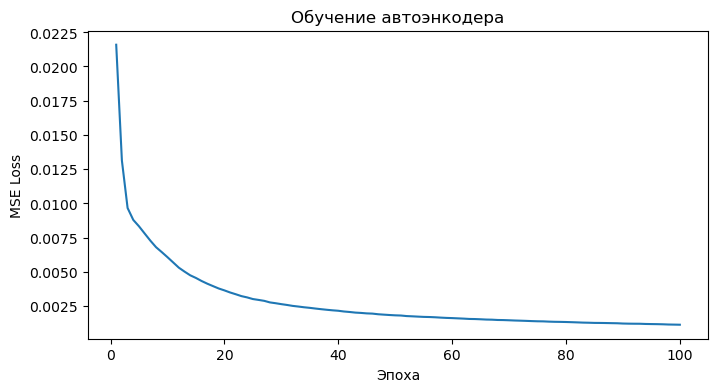

In [169]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses)

plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.title("Обучение автоэнкодера")
plt.show()

#### Во время обучения автоэнкодера ошибка восстановления (MSE Loss) последовательно снижалась. На первых эпохах ошибка уменьшалась особенно быстро, затем снижение стало более плавным. Это показывает, что автоэнкодер обучился восстанавливать исходные семантические эмбеддинги из их сжатого 32-мерного представления.